In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

data = pd.DataFrame({
    "study_hours": [2, 4, 6, 8, 5, 3, 7, 9, 4, 6,
                    8,],

    "attendance": [60, 70, 80, 90, 75, 65, 85, 95, 72, 82,
                   88,],

    "previous_score": [45, 55, 65, 80, 60, 50, 75, 88, 58, 70,
                       82,],

    "assignment_score": [50, 60, 70, 85, 65, 55, 80, 90, 62, 75,
                         88,],

    "sleep_hours": [5, 6, 7, 8, 6, 5, 7, 8, 6, 7,
                    8,],

    "final_score": [45, 55, 68, 85, 63, 50, 78, 92, 58, 72,
                    88,]
})

data

,study_hours,attendance,previous_score,assignment_score,sleep_hours,final_score
0,2,60,45,50,5,45
1,4,70,55,60,6,55
2,6,80,65,70,7,68
3,8,90,80,85,8,85
4,5,75,60,65,6,63
5,3,65,50,55,5,50
6,7,85,75,80,7,78
7,9,95,88,90,8,92
8,4,72,58,62,6,58
9,6,82,70,75,7,72


In [3]:
print("Dataset Shape:", data.shape)

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape: (11, 6)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   study_hours       11 non-null     int64
 1   attendance        11 non-null     int64
 2   previous_score    11 non-null     int64
 3   assignment_score  11 non-null     int64
 4   sleep_hours       11 non-null     int64
 5   final_score       11 non-null     int64
dtypes: int64(6)
memory usage: 660.0 bytes
None

Missing Values:
study_hours         0
attendance          0
previous_score      0
assignment_score    0
sleep_hours         0
final_score         0
dtype: int64


In [4]:
X = data.drop("final_score", axis=1)

y = data["final_score"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   study_hours  attendance  previous_score  assignment_score  sleep_hours
0            2          60              45                50            5
1            4          70              55                60            6
2            6          80              65                70            7
3            8          90              80                85            8
4            5          75              60                65            6

Target:
0    45
1    55
2    68
3    85
4    63
Name: final_score, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8, 5)
Testing data: (3, 5)


In [6]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[56.56 56.56 70.02]


In [8]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 3))

Model Performance
------------------
MAE : 6.7
RMSE: 7.76
R² Score: 0.562


In [9]:
comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred
})

comparison.head(10)

,Actual Score,Predicted Score
0,50,56.56
1,45,56.56
2,72,70.02


In [10]:
new_student = pd.DataFrame({
    "study_hours": [7],
    "attendance": [85],
    "previous_score": [75],
    "assignment_score": [80],
    "sleep_hours": [7]
})

prediction = model.predict(new_student)

print("Predicted Final Score:",
      round(prediction[0], 2))

Predicted Final Score: 77.68


In [11]:
score = prediction[0]

if score >= 75:
    category = "Good Performance"
elif score >= 50:
    category = "Average Performance"
else:
    category = "Needs Improvement"

print("Predicted Score:", round(score, 2))
print("Performance Category:", category)

Predicted Score: 77.68
Performance Category: Good Performance


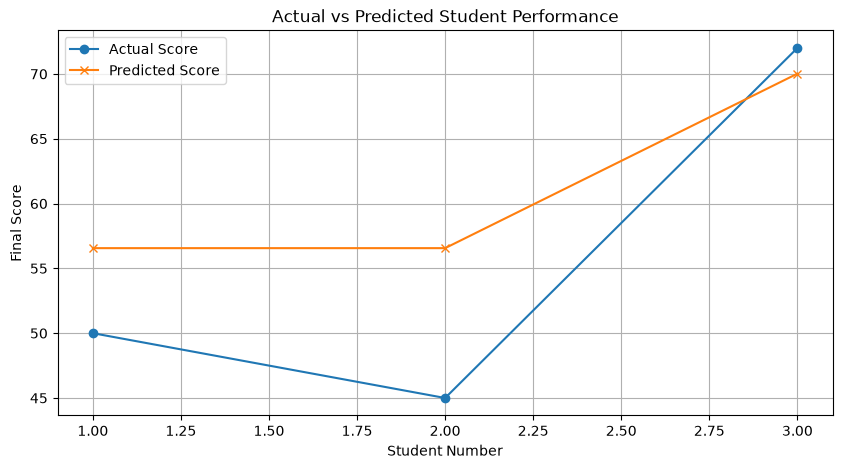

In [12]:
import matplotlib.pyplot as plt

students = range(1, len(y_test) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    students,
    y_test.values,
    marker='o',
    label='Actual Score'
)

plt.plot(
    students,
    y_pred,
    marker='x',
    label='Predicted Score'
)

plt.xlabel("Student Number")
plt.ylabel("Final Score")
plt.title("Actual vs Predicted Student Performance")

plt.legend()
plt.grid(True)

plt.show()